In [1]:
!rm -rf SteLA_Project
!git clone --recurse-submodules https://github.com/the-tuning-machine/SteLA_Project.git
%cd SteLA_Project
!uv sync

Cloning into 'SteLA_Project'...
remote: Enumerating objects: 44, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 44 (delta 20), reused 37 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (44/44), 6.13 MiB | 8.73 MiB/s, done.
Resolving deltas: 100% (20/20), done.
Submodule 'nanoGPT' (https://github.com/karpathy/nanoGPT) registered for path 'nanoGPT'
Cloning into '/content/SteLA_Project/nanoGPT'...
remote: Enumerating objects: 689, done.        
remote: Total 689 (delta 0), reused 0 (delta 0), pack-reused 689 (from 1)        
Receiving objects: 100% (689/689), 975.25 KiB | 30.48 MiB/s, done.
Resolving deltas: 100% (382/382), done.
Submodule path 'nanoGPT': checked out '3adf61e154c3fe3fca428ad6bc3818b27a3b8291'
/content/SteLA_Project
Using CPython 3.12.12 interpreter at: /usr/bin/python3
Creating virtual environment at: .venv
Resolved 60 packages in 772ms                                        
Installed 58 packa

In [2]:
import torch

torch.cuda.is_available()

True

In [3]:
!uv run python benchmark.py

Device: cuda (Tesla T4)

Model          Rank    Train   Total  Opt MB  Peak MB   Fwd ms  Bwd ms Step ms Total ms   Samp/s
Transformer       -      792     792    0.01    18.19     0.67    1.01    0.43     2.11    15194
LoRA              1      128     920    0.00    18.19     1.32    1.57    0.45     3.35     9559
StelLA            1      132     924    0.00    21.03     1.44    2.10    5.23     8.77     3650
Transformer       -      792     792    0.01    18.20     0.77    1.23    0.48     2.49    12865
LoRA              2      256    1048    0.00    18.21     1.40    1.74    0.46     3.61     8875
StelLA            2      272    1064    0.00    21.03     1.61    2.35    6.31    10.27     3116
Transformer       -      792     792    0.01    18.20     0.78    1.30    0.50     2.58    12403
LoRA              4      512    1304    0.00    18.21     1.48    1.94    0.50     3.93     8152
StelLA            4      576    1368    0.00    21.03     1.62    2.32    6.47    10.41     3074
Trans

benchmark_gpu_memory_phases.png


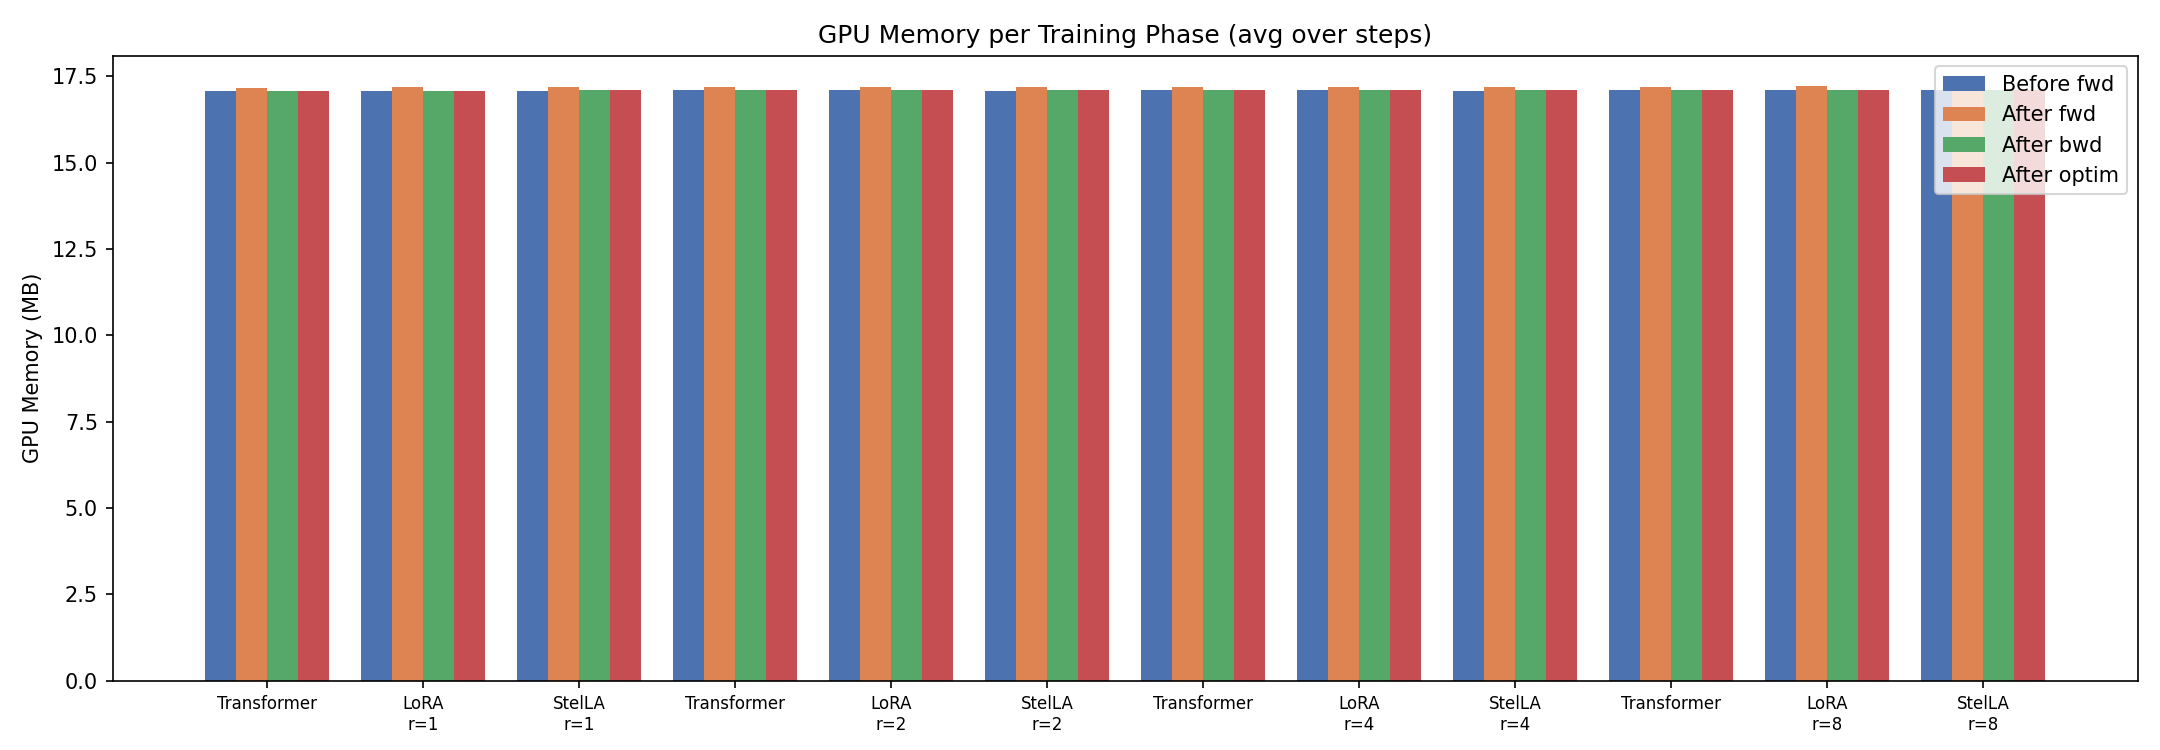

benchmark_gpu_memory_timeline.png


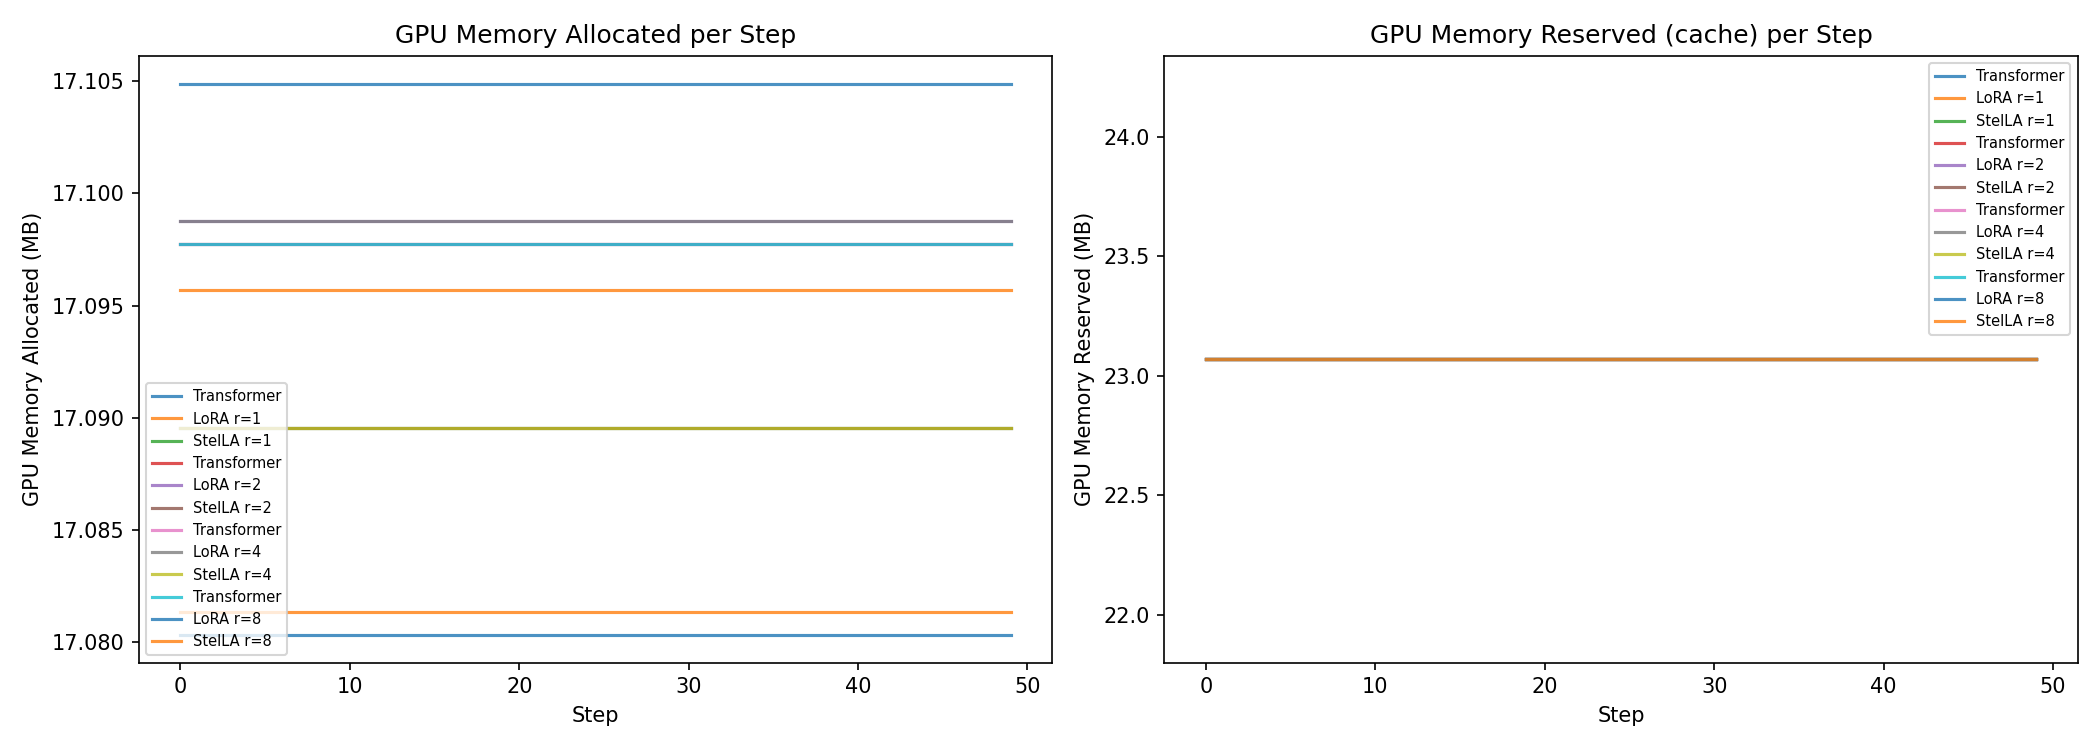

benchmark_peak_memory.png


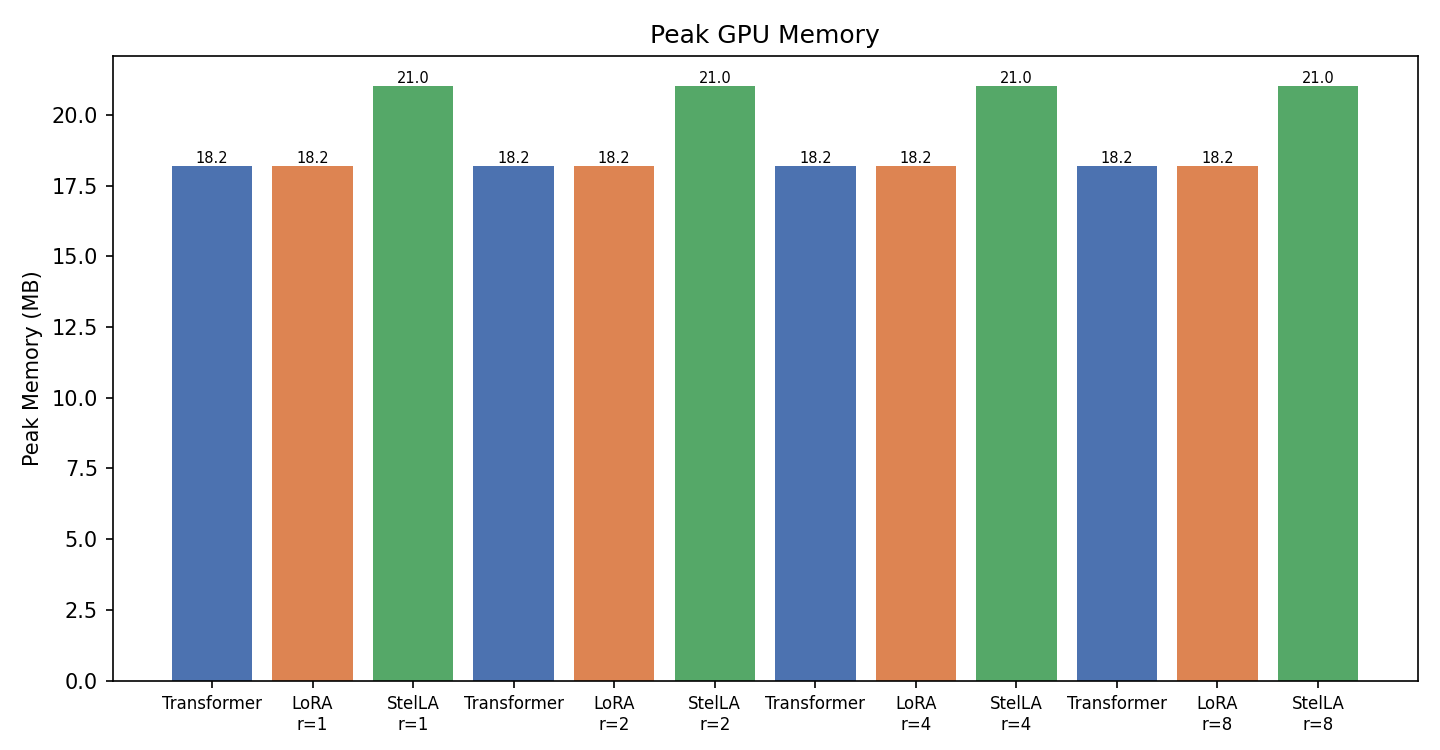

benchmark_step_time_timeline.png


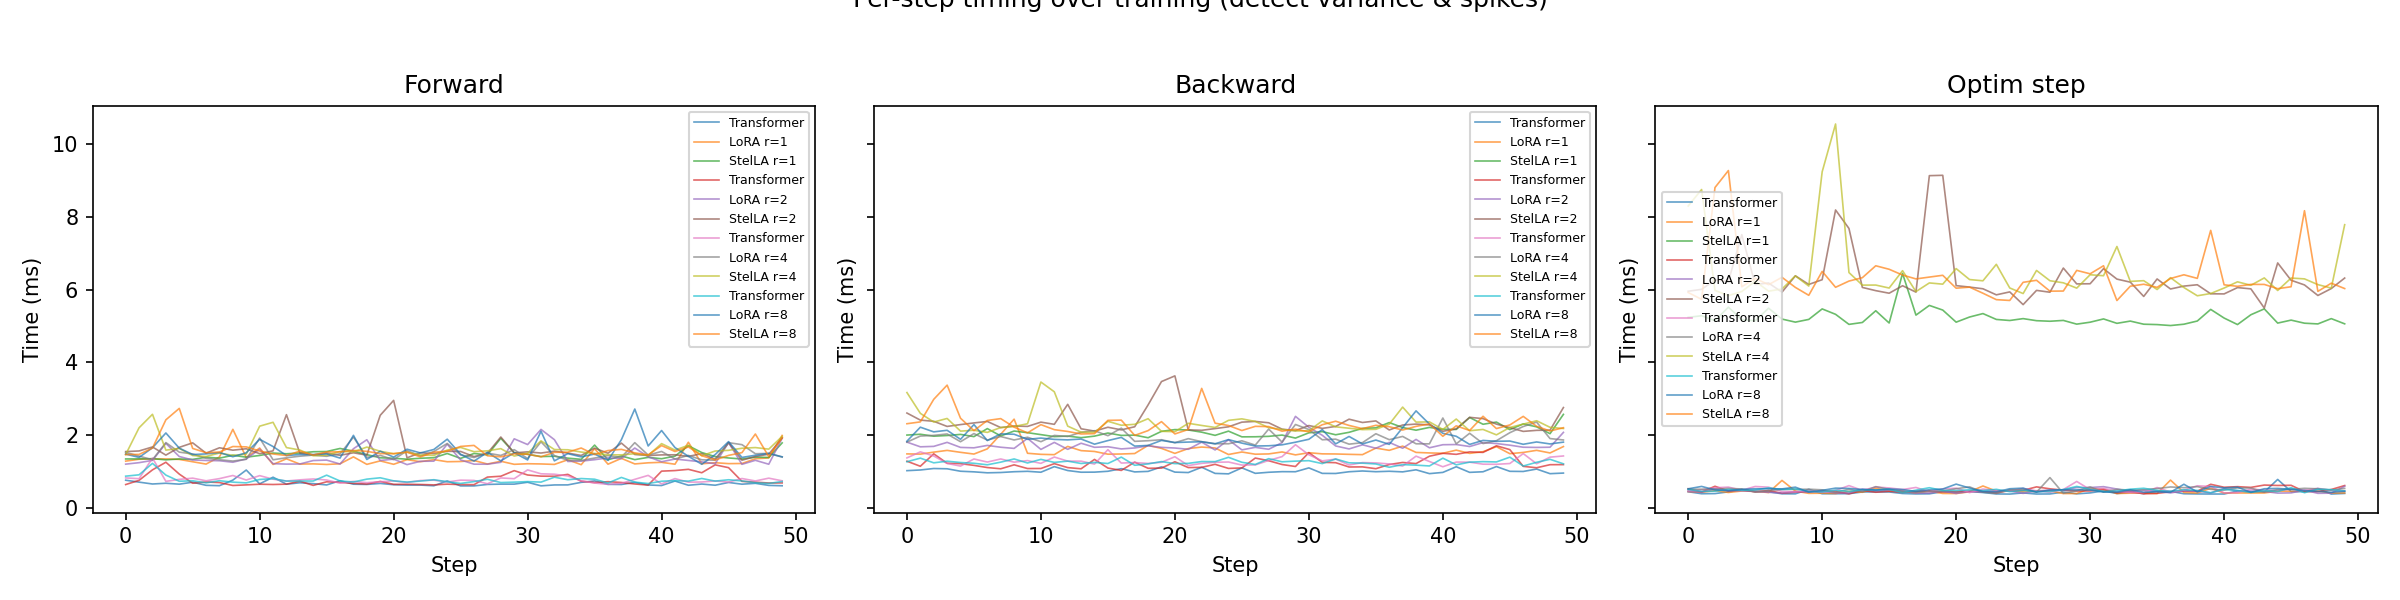

benchmark_throughput.png


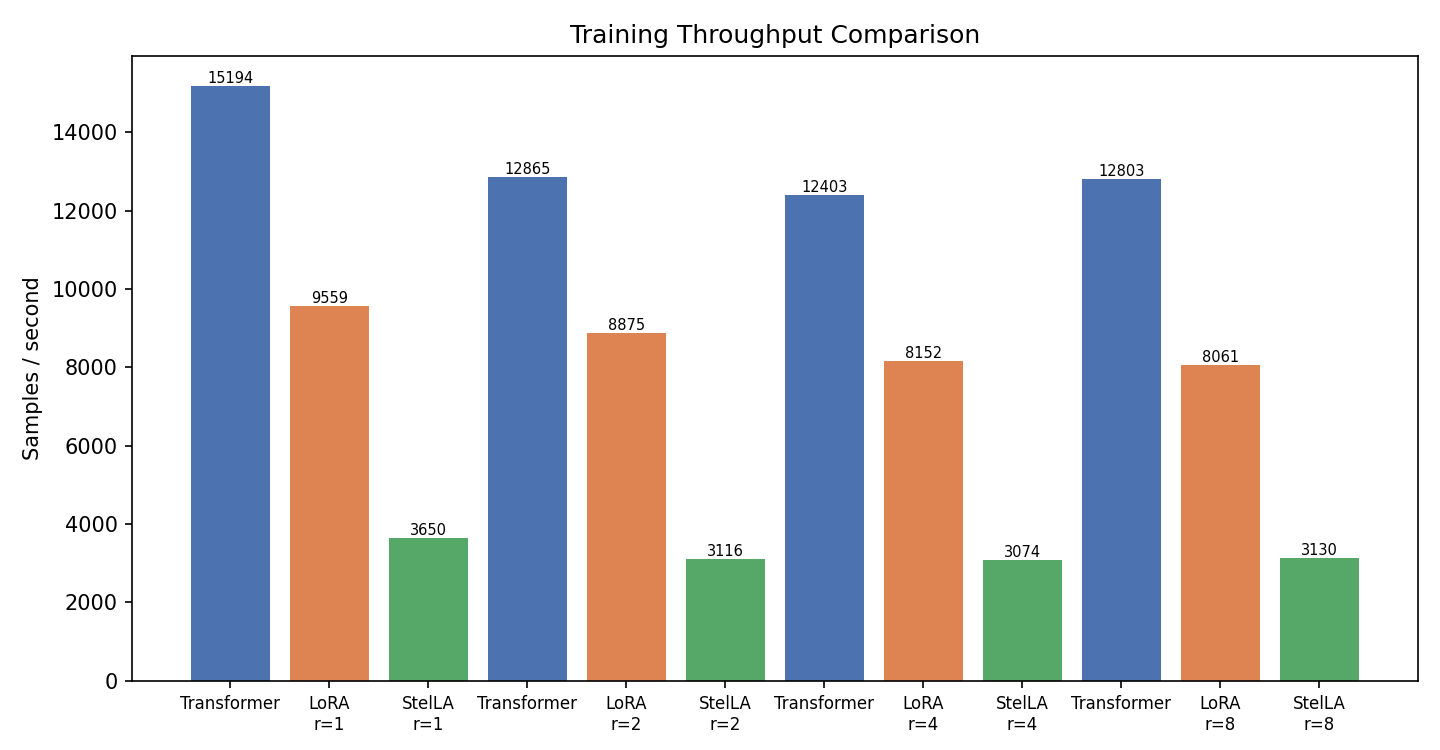

benchmark_time_breakdown.png


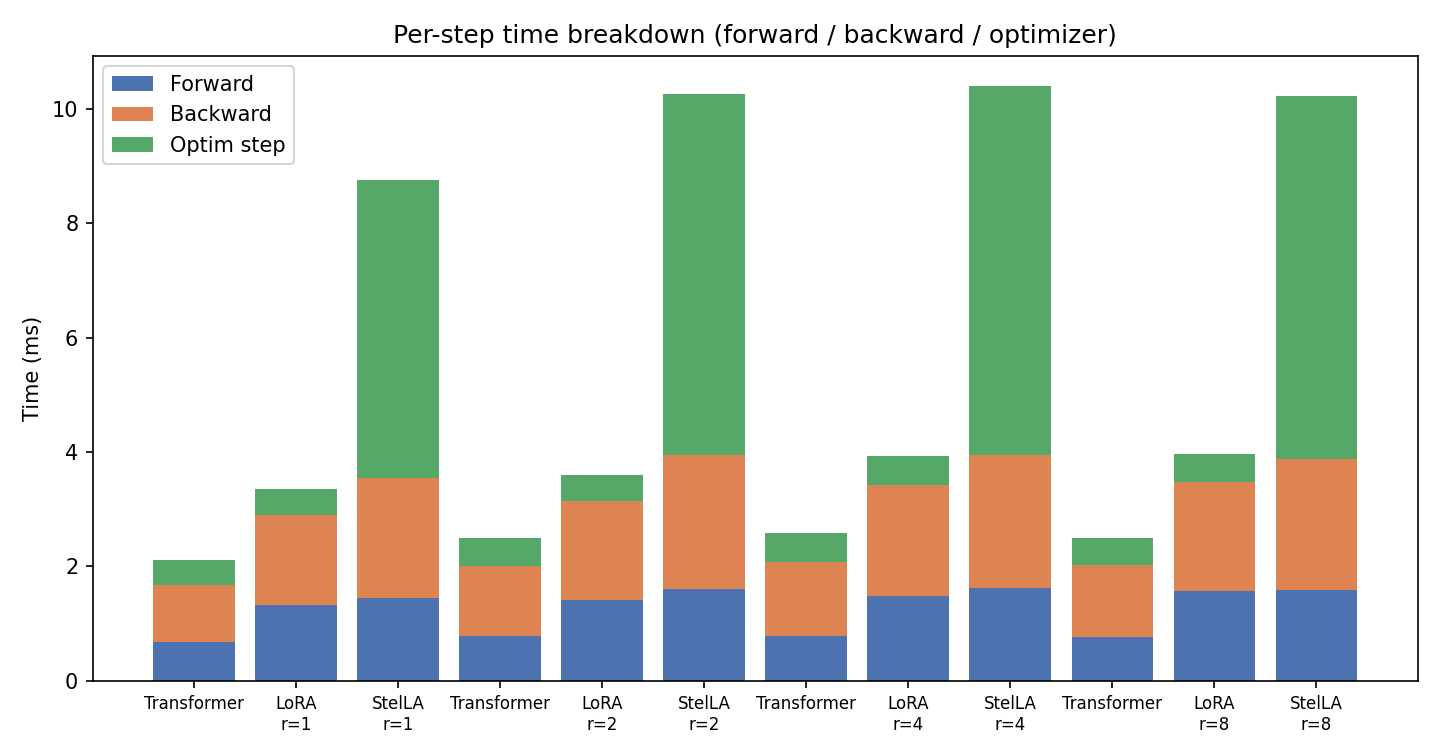

In [4]:
from IPython.display import display, Image                                                                                                  
import glob
                                                                                                                                            
for img in sorted(glob.glob("benchmark_*.png")):                                                                                            
    print(img)                                                                                                                              
    display(Image(filename=img))                                                                                                            
                                                                                                               
# from google.colab import files                                                                                                              
# for img in sorted(glob.glob("benchmark_*.png")):                                                                                            
#     files.download(img)
                            

In [9]:
!MPLBACKEND=agg uv run python main.py

both model on an equal footing
⠋ Overall ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   0% 0:00:00
Model 1/5
  LoRA fits StelLA━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   0% 0:00:00
    ⚡ Parallel mode — 20 sub-iterations batched on CUDA  0% 0:00:00
    Iteration 1/20━━━━━━━━━━━   0% 0:00:00
      Sub-iterations 1..20/20 (batch=20)
/content/SteLA_Project/.venv/lib/python3.12/site-packages/torch/autograd/graph.p  0% 0:00:01
y:865: UserWarning: There is a performance drop because we have not yet 
implemented the batching rule for 
aten::_scaled_dot_product_efficient_attention_backward. Please file us an issue 
on GitHub so that we can prioritize its implementation. (Triggered internally at
/pytorch/aten/src/ATen/functorch/BatchedFallback.cpp:80.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine 
to run the backward pass
        Epoch 1/10, Loss (mean): 0.039997 0:00:01
        Epoch 2/10, Loss (mean): 0.017002 0:00:01
        Epoch 3/10, Loss (mean): 0.008343 0:00:01
